# Experiment No: 2
## Title: Develop a Ridge and Lasso regression model to predict the number of bike rentals based on weather conditions and time. Dataset: Bike Sharing Dataset (UCI)

---


### Name : Jitendra Baravkar
### Roll. No: 2317005
### Batch: AI-A (A)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

###Step 1  Import all the necessary library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

###Step 2 :  Load the dataset

In [2]:
df = pd.read_csv('bike.csv')

In [ ]:
display(df.head())

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [ ]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


None

In [ ]:
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [ ]:
df.shape

(17379, 17)

###Step 3 : Data Exploration and Cleaning

In [ ]:
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [ ]:
df.isnull()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
17375,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
17376,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
17377,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


###Step 4 Data Preparation :

In [ ]:
columns_to_drop = ['instant', 'dteday', 'casual', 'registered']

df = df.drop(columns_to_drop, axis=1)

In [ ]:
df.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


1. Separate Features (X) and Target (y)

   X contains all columns EXCEPT our target, 'cnt'

   y contains ONLY the 'cnt' column

In [ ]:
X = df.drop('cnt', axis=1)
y = df['cnt']

In [ ]:
print(X.head())

   season  yr  mnth  hr  holiday  weekday  workingday  weathersit  temp  \
0       1   0     1   0        0        6           0           1  0.24   
1       1   0     1   1        0        6           0           1  0.22   
2       1   0     1   2        0        6           0           1  0.22   
3       1   0     1   3        0        6           0           1  0.24   
4       1   0     1   4        0        6           0           1  0.24   

    atemp   hum  windspeed  
0  0.2879  0.81        0.0  
1  0.2727  0.80        0.0  
2  0.2727  0.80        0.0  
3  0.2879  0.75        0.0  
4  0.2879  0.75        0.0  


In [ ]:

print(y.head())

0    16
1    40
2    32
3    13
4     1
Name: cnt, dtype: int64


 2.Split Data for Training and Testing

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print("Rows in training set:", len(X_train))
print("Rows in testing set:", len(X_test))

Rows in training set: 13903
Rows in testing set: 3476


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

###Step 5 Model Training:

1.  Train the Ridge Regression Model

     'alpha' controls the strength of the penalty.

In [ ]:
from sklearn.linear_model import Ridge, Lasso

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)


Ridge()

2. Train the Lasso Regression Model

In [ ]:
lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train_scaled, y_train)


Lasso()

###Step 6: Evaluation of models

Evaluate the Ridge Model

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


ridge_predictions = ridge_model.predict(X_test_scaled)

ridge_mae = mean_absolute_error(y_test, ridge_predictions)
ridge_mse = mean_squared_error(y_test, ridge_predictions)
ridge_r2 = r2_score(y_test, ridge_predictions)

In [ ]:
print("  Ridge MAE: ",ridge_mae)
print("  Ridge MSE: ",ridge_mse)
print("  Ridge R-squared:", ridge_r2)

  Ridge MAE:  104.80310773108502
  Ridge MSE:  19379.85402182032
  Ridge R-squared: 0.3879803481501569


 Evaluate the Lasso Model

In [ ]:
lasso_predictions = lasso_model.predict(X_test_scaled)

lasso_mae = mean_absolute_error(y_test, lasso_predictions)
lasso_mse = mean_squared_error(y_test, lasso_predictions)
lasso_r2 = r2_score(y_test, lasso_predictions)

In [ ]:
print("  Lasso MAE:",lasso_mae)
print("  Lasso MSE: ",lasso_mse)
print("  Lasso R-squared:",lasso_r2)

  Lasso MAE: 104.55075892814212
  Lasso MSE:  19381.61065771837
  Lasso R-squared: 0.38792487323845004


Comperision





In [ ]:
ridge_coeffs = pd.Series(ridge_model.coef_, index=X.columns)
lasso_coeffs = pd.Series(lasso_model.coef_, index=X.columns)

create a pandas DataFrame in which two columns named 'Ridge' and 'Lasso' and to use our feature names as the row labels.

In [ ]:

coeffs_df = pd.DataFrame({'Ridge': ridge_coeffs, 'Lasso': lasso_coeffs})
print(coeffs_df)

                Ridge      Lasso
season      22.703883  22.040639
yr          41.419198  40.443814
mnth         0.413528   0.000000
hr          52.957733  52.226695
holiday     -4.026828  -3.312309
weekday      3.574790   2.682154
workingday   1.821776   0.992634
weathersit  -2.194665  -1.289584
temp        19.167324  20.959631
atemp       35.269973  33.025716
hum        -38.453415 -38.300366
windspeed    4.216552   3.079393


<Figure size 1200x600 with 0 Axes>

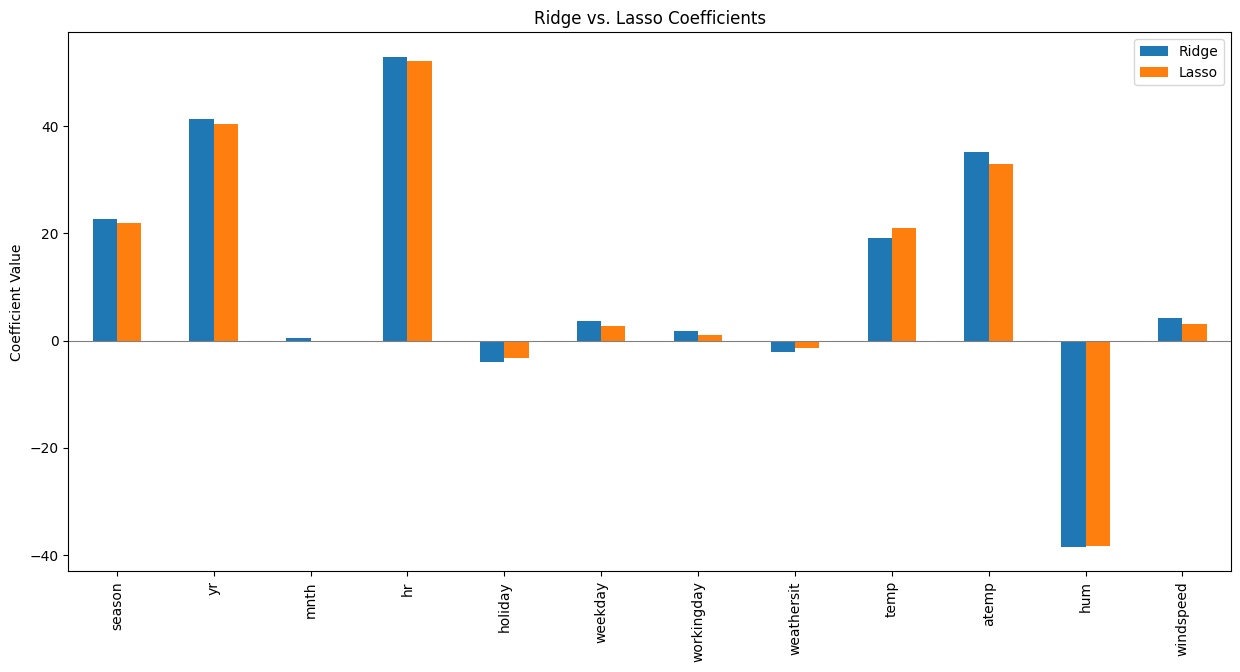

In [ ]:
plt.figure(figsize=(12, 6))
coeffs_df.plot(kind='bar', figsize=(15, 7))
plt.title('Ridge vs. Lasso Coefficients')
plt.ylabel('Coefficient Value')
plt.axhline(0, color='grey', linewidth=0.8) # Adds a zero line
plt.show()